In [1]:
!pip install shap

  Using cached shap-0.50.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (25 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached shap-0.50.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (1.1 MB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.3.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is 

In [3]:
!pip install polars

  Using cached polars-1.38.1-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.38.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached polars-1.38.1-py3-none-any.whl (810 kB)
Using cached polars_runtime_32-1.38.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (45.8 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]2m1/2 [polars]


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import math
import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [5]:
# Read aggregated data from S3
df = pl.read_parquet("s3://msds-26.2-data/clean/combined_recovery_data_aggregated_with_new_features.parquet")

In [6]:
# drop all reason_code related columns
df = df.drop(['proportion_reason_code_E', 'proportion_reason_code_O', 'proportion_reason_code_type_LLSI', 
              'proportion_stranded', 'proportion_reason_code_type_N', 'proportion_reason_code_type_MCF',
              'proportion_reason_code_type_ALSI'])

In [7]:
# drop all buffer rows
df = df.filter(pl.col('num_records').is_not_null())

In [8]:
# Sample out 5% of data 
df_sample = df.sample(fraction=0.05)

In [9]:
df_sample_pd = df_sample.to_pandas()

In [10]:
# Define categorical columns
df_sample_pd['hashed_fc'] = df_sample_pd['hashed_fc'].astype('category')
df_sample_pd['gl_product_group'] = df_sample_pd['gl_product_group'].astype('category')
df_sample_pd['country'] = df_sample_pd['country'].astype('category')
df_sample_pd['country_state'] = df_sample_pd['country_state'].astype('category')
df_sample_pd['zip_code'] = df_sample_pd['zip_code'].astype('category')
df_sample_pd['site_type'] = df_sample_pd['site_type'].astype('category')
df_sample_pd['site_category'] = df_sample_pd['site_category'].astype('category')

In [11]:
# Sort dataframe
df_sample_pd.sort_values(by=['hashed_fc', 'gl_product_group', 'week_date'], inplace=True)

In [12]:
df_sample_pd

,hashed_fc,gl_product_group,start,end,week_date,year,month,week,num_records,proportion_macro_category_RETAIL,...,cogs_per_weight_mean_slope_4wk,cogs_per_weight_std_mom_1wk,cogs_per_weight_std_mom_1wk_pct,cogs_per_weight_std_mom_4wk,cogs_per_weight_std_slope_4wk,proportion_recovery_mom_1wk,proportion_recovery_mom_1wk_pct,proportion_recovery_mom_4wk,proportion_recovery_slope_4wk,weeks_since_first_appearance
186367,0000c60d3b14250deb1312b21a448a53591a6668f530c8...,196.0,2022-01-03,2022-07-04,2022-05-23,2022,5,21,1,1.0,...,-0.003435,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,22
271024,0000c60d3b14250deb1312b21a448a53591a6668f530c8...,196.0,2022-01-03,2022-07-04,2022-05-30,2022,5,22,1,1.0,...,-0.009031,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,23
334067,0000c60d3b14250deb1312b21a448a53591a6668f530c8...,200.0,2022-01-03,2022-07-04,2022-01-03,2022,1,1,1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
225998,0000c60d3b14250deb1312b21a448a53591a6668f530c8...,200.0,2022-01-03,2022-07-04,2022-01-17,2022,1,3,1,1.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,2
198077,0000c60d3b14250deb1312b21a448a53591a6668f530c8...,200.0,2022-01-03,2022-07-04,2022-02-14,2022,2,7,1,1.0,...,0.000565,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290305,fff3d7465104aa75ee0ca31d193398d033ebb8aa6e30b1...,121.0,2024-01-01,2025-12-22,2025-02-03,2025,2,6,1,1.0,...,0.000466,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,59
383441,fff3d7465104aa75ee0ca31d193398d033ebb8aa6e30b1...,121.0,2024-01-01,2025-12-22,2025-04-14,2025,4,16,1,1.0,...,-0.000071,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,70
129401,fff3d7465104aa75ee0ca31d193398d033ebb8aa6e30b1...,121.0,2024-01-01,2025-12-22,2025-08-25,2025,8,35,1,1.0,...,0.000018,NaN,NaN,NaN,NaN,0.0,NaN,0.0,0.0,92
221171,fffda6de5ef71646faf113a5359c3260bb90006a737dc5...,196.0,2022-01-03,2022-07-04,2022-01-31,2022,1,5,1,1.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,4


In [13]:
df_sample_pd['year'].value_counts()

year
2025    123647
2024    122014
2023    104232
2022     90846
Name: count, dtype: int64

In [14]:
df_sample_pd.columns

Index(['hashed_fc', 'gl_product_group', 'start', 'end', 'week_date', 'year',
       'month', 'week', 'num_records', 'proportion_macro_category_RETAIL',
       ...
       'cogs_per_weight_mean_slope_4wk', 'cogs_per_weight_std_mom_1wk',
       'cogs_per_weight_std_mom_1wk_pct', 'cogs_per_weight_std_mom_4wk',
       'cogs_per_weight_std_slope_4wk', 'proportion_recovery_mom_1wk',
       'proportion_recovery_mom_1wk_pct', 'proportion_recovery_mom_4wk',
       'proportion_recovery_slope_4wk', 'weeks_since_first_appearance'],
      dtype='object', length=102)

In [15]:
df_sample_pd.drop(columns=['proportion_recovery_mom_1wk_pct', 'proportion_recovery_mom_4wk', 'proportion_recovery_slope_4wk', 'proportion_recovery_mom_1wk', 'cogs_per_weight_std_mom_1wk_pct'], inplace=True)

In [16]:
df_sample_pd.drop(columns=['units_total_mom_1wk_pct', 'cogs_total_mom_1wk_pct', 'weight_total_mom_1wk_pct', 'cogs_per_unit_mean_mom_1wk_pct', 'cogs_per_unit_std_mom_1wk_pct', 'cogs_per_weight_mean_mom_1wk_pct'], inplace=True)

In [17]:
# Use 2025 as test data
train = df_sample_pd[df_sample_pd['year'] != 2025]
test = df_sample_pd[df_sample_pd['year'] == 2025]

# Use all features

In [31]:
y_train = train['proportion_recovery']
X_train = train.drop(columns=['proportion_recovery', 'num_records', 'start', 'end', 'week_date'])

y_test = test['proportion_recovery']
X_test = test.drop(columns=['proportion_recovery', 'num_records', 'start', 'end', 'week_date'])


In [32]:
X_train.describe()

,year,month,week,proportion_macro_category_RETAIL,proportion_macro_category_FBA,proportion_hazmat,proportion_food,proportion_non_food,proportion_pet_food,units_total,...,cogs_per_unit_std_mom_1wk,cogs_per_unit_std_mom_4wk,cogs_per_unit_std_slope_4wk,cogs_per_weight_mean_mom_1wk,cogs_per_weight_mean_mom_4wk,cogs_per_weight_mean_slope_4wk,cogs_per_weight_std_mom_1wk,cogs_per_weight_std_mom_4wk,cogs_per_weight_std_slope_4wk,weeks_since_first_appearance
count,126519.000000,126519.000000,126519.000000,126519.000000,126519.000000,126519.0,126519.000000,126519.000000,126519.000000,126519.000000,...,61122.000000,59293.000000,63156.000000,1.149640e+05,109894.000000,107740.000000,61087.000000,59261.000000,6.312500e+04,126519.000000
mean,2023.092081,6.538638,26.480173,0.656470,0.343530,0.0,0.046104,0.949608,0.004289,3763.963309,...,-0.809588,0.035750,0.359565,8.339873e-03,0.000066,-0.011737,0.008313,0.010409,-1.248744e-02,75.719015
std,0.815460,3.505020,15.320110,0.372835,0.372835,0.0,0.209711,0.213080,0.042663,16543.574807,...,79.204537,86.258753,51.757121,3.232620e+00,2.120455,1.989320,2.941649,3.033369,1.714849e+00,51.569424
min,2022.000000,1.000000,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,4.040000,...,-2669.645493,-3101.422065,-2539.932615,-4.158188e+02,-289.162838,-285.377517,-97.351566,-80.120902,-3.014386e+02,0.000000
25%,2022.000000,4.000000,13.000000,0.400000,0.000000,0.0,0.000000,1.000000,0.000000,8.530000,...,-3.208480,-3.492730,-2.305273,-3.662394e-03,-0.004355,-0.004051,-0.012796,-0.014146,-1.212909e-02,32.000000
50%,2023.000000,7.000000,27.000000,0.684211,0.315789,0.0,0.000000,1.000000,0.000000,47.170000,...,-0.007445,-0.000149,0.002968,-3.562639e-08,-0.000001,-0.000002,0.000004,0.000002,4.997106e-07,68.000000
75%,2024.000000,10.000000,40.000000,1.000000,0.600000,0.0,0.000000,1.000000,0.000000,603.990000,...,2.908413,3.373496,2.210132,3.658260e-03,0.004351,0.003843,0.012760,0.014069,1.237957e-02,116.000000
max,2024.000000,12.000000,52.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,884809.790000,...,3559.246207,2587.854130,2341.961858,7.151331e+02,432.158998,289.728023,611.159487,611.161386,7.248731e+01,189.000000


In [33]:
# Initialize the regressor
regressor = xgb.XGBRegressor(
    n_estimators=100,
    enable_categorical=True,
    tree_method='hist' # 'hist' is often recommended with categorical features
)

# Fit the model (X is your feature DataFrame, y is your target variable)
regressor.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [21]:
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
y_pred = regressor.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 0.129
R²: 0.860


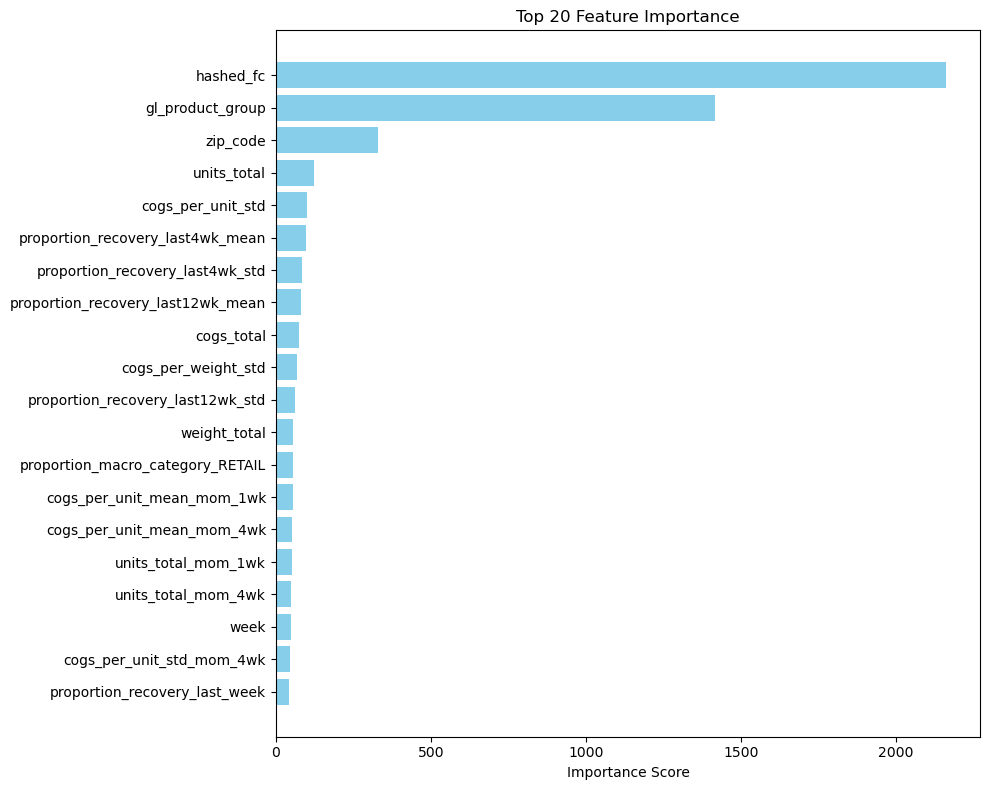

In [36]:
importance = regressor.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

## Use historical features only - Simulate forecasting use case

In [18]:
y_train = train['proportion_recovery']
X_train = train.drop(columns=['proportion_recovery', 'num_records', 'start', 'end', 'week_date', 'units_total',
       'cogs_total', 'weight_total', 'cogs_per_unit_mean', 'cogs_per_unit_std',
       'cogs_per_weight_mean', 'cogs_per_weight_std'])

y_test = test['proportion_recovery']
X_test = test.drop(columns=['proportion_recovery', 'num_records', 'start', 'end', 'week_date', 'units_total',
       'cogs_total', 'weight_total', 'cogs_per_unit_mean', 'cogs_per_unit_std',
       'cogs_per_weight_mean', 'cogs_per_weight_std'])

In [19]:
# Initialize the regressor
regressor = xgb.XGBRegressor(
    n_estimators=100,
    enable_categorical=True,
    tree_method='hist' # 'hist' is often recommended with categorical features
)

# Fit the model (X is your feature DataFrame, y is your target variable)
regressor.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [22]:
y_pred = regressor.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 0.129
R²: 0.860


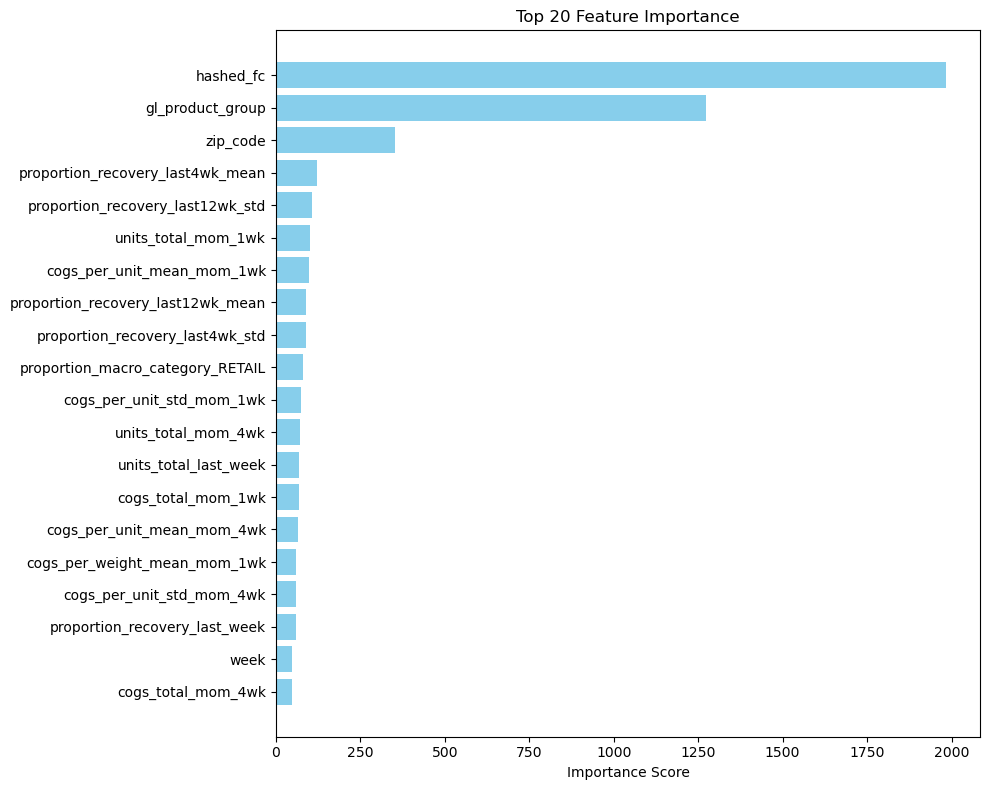

In [23]:
importance = regressor.get_booster().get_score(importance_type='weight')

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color='skyblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance')
plt.tight_layout()
plt.show()

In [24]:
import shap

In [25]:
explainer = shap.TreeExplainer(regressor)
shap_values = explainer(X_train)

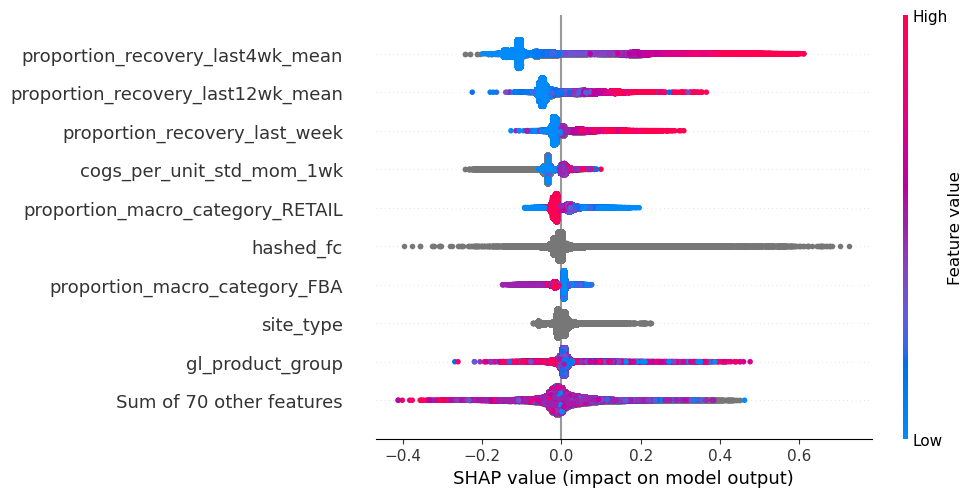

In [26]:
shap.plots.beeswarm(shap_values)